In [1]:
import os
os.chdir("..")

In [2]:
from src.data_processing.size_dataset import ParticleDataset
from src.models.resnet import ResNet18
from src.trainers.trainersize import TrainerSize, generate_label_distribution
from torch.utils.data import DataLoader

In [4]:
# import os
# os.chdir("/nfshome/narjis")
dataset_path = "/nfshome/narjis/Downloads/brightfield_particles_y.hdf5"
classes = [1]
plot_dataset = ParticleDataset(
    h5_path=dataset_path,
    classes=classes,
    mean=None,
    std=None,
    padding=False,
    transform=None,
    indices=None,
)

Computed statistics: mean = 8038.4417, std = 1153.0563


In [5]:
ParticleDataset(
    h5_path=dataset_path,
    classes=[0,1],
    mean=None,
    std=None,
    padding=False,
    transform=None,
    indices=None,
)

Computed statistics: mean = 7541.1983, std = 1316.1215


In [6]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ResNet18(num_classes=1)  # For regression, output is a single value
checkpoint_path = "/nfshome/narjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_2025-06-04_17-42-55/best_model.pth"
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device)['model_state_dict'])
model = model.to(device)

Using cache found in /nfshome/narjis/.cache/torch/hub/pytorch_vision_v0.10.0
/tmp/ipykernel_2463641/4154100593.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load

In [7]:
model.eval()
target_distribution = generate_label_distribution(num_points=16000, mean=302, std=25, min_value=150, max_value=None)
# images = [plot_dataset[i][0].unsqueeze(0) for i in range(len(plot_dataset))]
# images = torch.cat(images, dim=0).to(device)
dataloader = DataLoader(
        plot_dataset,
        batch_size=4000,
        drop_last=False,
    )

In [8]:
import torch
from torch.utils.data import DataLoader
# Create DataLoader for the dataset
predictions = []
model.eval()  # Set the model to evaluation mode
for batch,_ in dataloader:
    images = batch.to(device)
    with torch.no_grad():
        outputs = model(images)
        predictions.append(outputs.cpu().numpy().flatten())
predictions = torch.cat([torch.tensor(pred) for pred in predictions], dim=0).numpy()

RuntimeError: Given groups=1, weight of size [64, 3, 7, 7], expected input[4000, 1, 16, 128] to have 3 channels, but got 1 channels instead

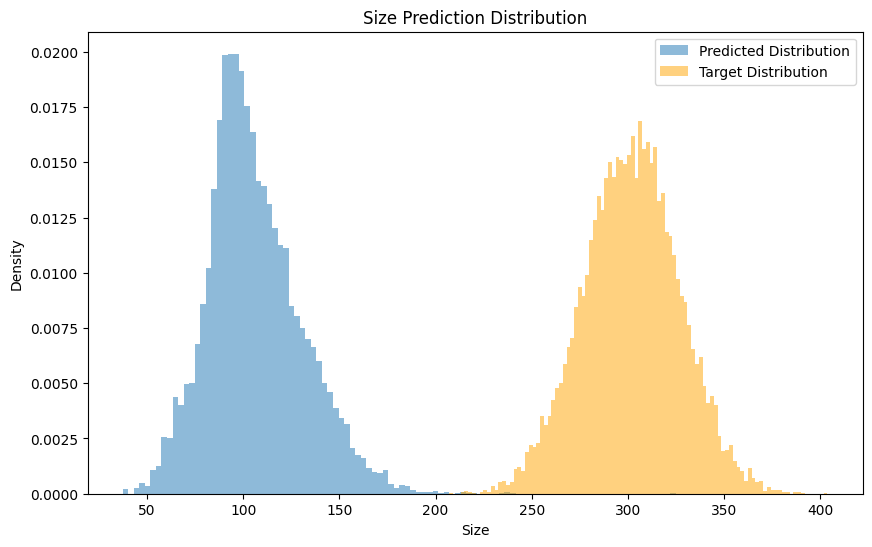

In [22]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(predictions, bins=100, density=True, alpha=0.5, label='Predicted Distribution')
ax.hist(target_distribution, bins=100, density=True, alpha=0.5, label='Target Distribution', color='orange')
ax.set_title('Size Prediction Distribution')
ax.set_xlabel('Size')
ax.set_ylabel('Density')
ax.legend()
plt.show()

In [32]:
from torch import nn
import torch
from torchinfo import summary
model = ResNet18(num_classes=1)  # For regression, output is a single value
model.resnet.maxpool = nn.Identity()
# model.resnet.avgpool = nn.Identity()
model.resnet(torch.randn(1, 1, 16, 124)).shape
summary(model, input_size=(1, 1, 16, 124),device="cuda")

Using cache found in /nfshome/narjis/.cache/torch/hub/pytorch_vision_v0.10.0


Layer (type:depth-idx)                        Output Shape              Param #
ResNet18                                      [1, 1]                    --
├─ResNet: 1-1                                 [1, 1]                    --
│    └─Conv2d: 2-1                            [1, 64, 8, 62]            3,136
│    └─BatchNorm2d: 2-2                       [1, 64, 8, 62]            128
│    └─ReLU: 2-3                              [1, 64, 8, 62]            --
│    └─Identity: 2-4                          [1, 64, 8, 62]            --
│    └─Sequential: 2-5                        [1, 64, 8, 62]            --
│    │    └─BasicBlock: 3-1                   [1, 64, 8, 62]            73,984
│    │    └─BasicBlock: 3-2                   [1, 64, 8, 62]            73,984
│    └─Sequential: 2-6                        [1, 128, 4, 31]           --
│    │    └─BasicBlock: 3-3                   [1, 128, 4, 31]           230,144
│    │    └─BasicBlock: 3-4                   [1, 128, 4, 31]           295,42

In [29]:
model.resnet

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p